# Spooky Author Identification — methodology 3: a character + word CNN trained from scratch

Methodologies 1 and 2 use hand-chosen representations (n-grams, style statistics). Here a small neural network **learns its own features** directly from
characters and words, with no pre-trained weights:

* **Character branch** — embeddings (32-d) of every character (case and punctuation kept), convolutions of width 3, 5 and 7 (96 filters each), max-pooled over the sentence (first 256 characters).
* **Word branch** — embeddings (100-d) of lower-cased word and punctuation tokens, convolutions of width 1, 2 and 3 (64 filters each), max-pooled (first 64 tokens).
* The six pooled vectors are concatenated, passed through dropout (0.5) and a linear layer to three logits; training minimises cross-entropy, $\mathcal L=-\log p_\theta(y\mid x)$, with AdamW.

An inner 10% of each fold's training rows selects the best epoch (lowest log loss) and stops training; the outer validation fold is **recorded every epoch and never selects anything**.
This is a *surface* run: one seed, at most 8 epochs, trained on a 16-core CPU sandbox by `train_cnn.py`. Probabilities are temperature-scaled with $T$ fitted on the other folds' out-of-fold predictions, as for every methodology.

In [1]:
import json, os
import numpy as np, pandas as pd, torch, torch.nn.functional as F
import matplotlib.pyplot as plt, seaborn as sns
from matplotlib.patches import Rectangle
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score
from sklearn.calibration import calibration_curve
import spooky_common as S, train_cnn as TC
sns.set_theme(style="whitegrid"); plt.rcParams["figure.dpi"] = 110
PAL = ["#4C72B0", "#C44E52", "#55A868"]; AU = S.AUTHORS; os.makedirs("assets", exist_ok=True)
train, test, folds, y = S.load(); res = TC.assemble(); assert res is not None, "run train_cnn.py first"; oof, tst, runs = res
cal, Ts, tcal = S.cv_temperature(oof, y, folds, tst); ev_raw, ev = S.evaluate(y, oof, folds), S.evaluate(y, cal, folds)
print(f"char+word CNN: log loss {ev['log_loss']:.4f} {np.round(ev['log_loss_ci95'], 4)} (raw {ev_raw['log_loss']:.4f}), accuracy {ev['accuracy']:.4f}, macro-F1 {ev['macro_f1']:.4f}; T per fold {np.round(Ts, 2).tolist()}")
print("best epoch per fold:", [r["best_epoch"] for r in runs], "| epochs run:", [r["n_epochs"] for r in runs], "| seconds per fold (16-core CPU, 5 folds in parallel):", [round(r["seconds"]) for r in runs])
S.save_method("cnn", cal, tcal, dict(method="character + word CNN from scratch", best_epochs=[r["best_epoch"] for r in runs], temperature_per_fold=Ts, raw=ev_raw, **ev))

char+word CNN: log loss 0.4822 [0.472  0.4924] (raw 0.4890), accuracy 0.8066, macro-F1 0.8064; T per fold [1.15, 1.24, 1.24, 1.23, 1.22]
best epoch per fold: [7, 5, 5, 5, 5] | epochs run: [8, 8, 8, 8, 8] | seconds per fold (16-core CPU, 5 folds in parallel): [173, 167, 165, 163, 172]


## 1. In-training statistics

Collected every epoch during training; the figure is drawn afterwards.

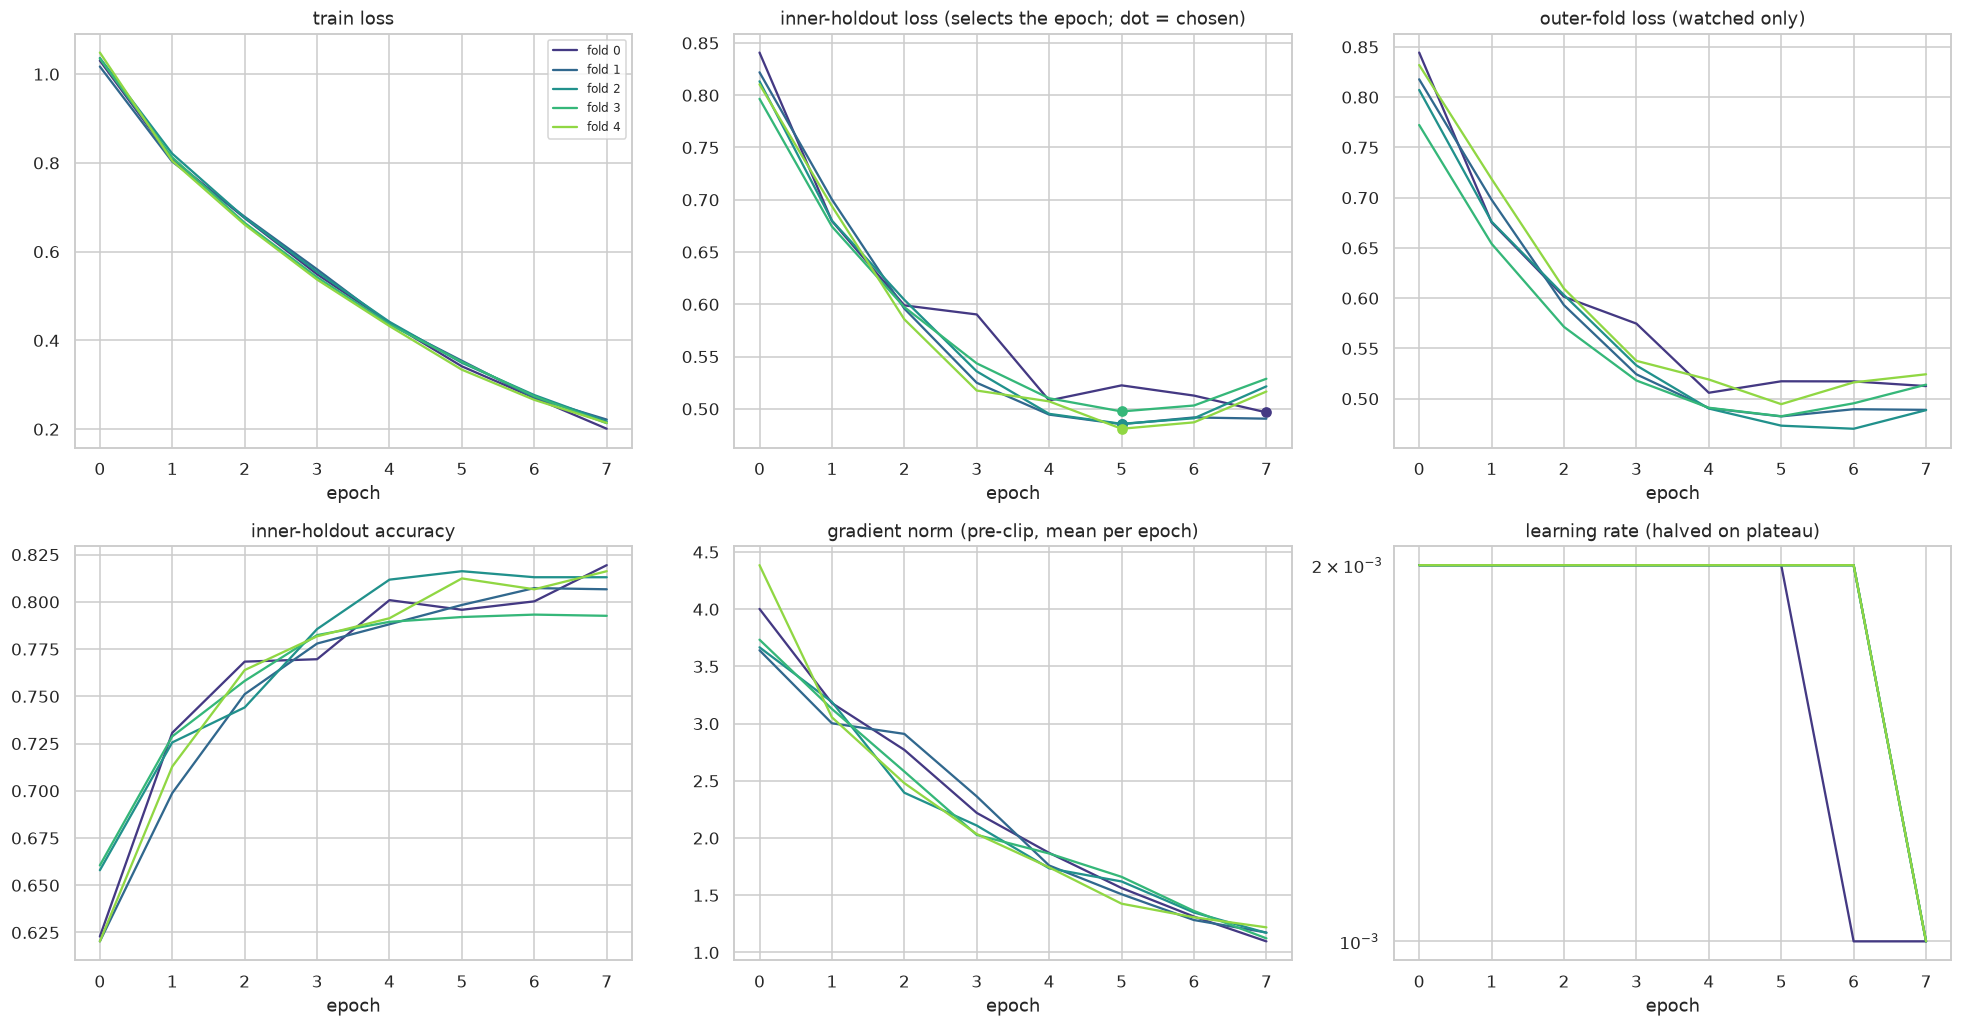

,fold,best_epoch,epochs,train_loss,inner_loss,outer_loss
0,0,7,8,0.2009,0.4966,0.5125
1,1,5,8,0.3540,0.4853,0.4824
2,2,5,8,0.3496,0.4857,0.4731
3,3,5,8,0.3517,0.4975,0.4825
4,4,5,8,0.3340,0.4809,0.4945


train loss at the chosen epoch is 0.318 against 0.489 held-out; 4 of 5 folds stopped by patience (inner loss rose after the best epoch), the rest hit the 8-epoch cap: the model overfits early, so regularisation or augmentation matters more than extra epochs


In [2]:
H = pd.concat([pd.DataFrame(r["history"]).assign(fold=r["fold"], best=r["best_epoch"]) for r in runs]); cs = sns.color_palette("viridis", 5)
fig, axes = plt.subplots(2, 3, figsize=(18, 9.5))
for k, g in H.groupby("fold"):
    c = cs[k]; axes[0, 0].plot(g.epoch, g.train_loss, color=c, label=f"fold {k}"); axes[0, 1].plot(g.epoch, g.inner_loss, color=c); axes[0, 1].plot(g.best.iloc[0], g.inner_loss.min(), "o", color=c)
    axes[0, 2].plot(g.epoch, g.mon_loss, color=c); axes[1, 0].plot(g.epoch, g.inner_acc, color=c); axes[1, 1].plot(g.epoch, g.grad_norm, color=c); axes[1, 2].plot(g.epoch, g.lr, color=c)
for ax, t in zip(axes.ravel(), ["train loss", "inner-holdout loss (selects the epoch; dot = chosen)", "outer-fold loss (watched only)", "inner-holdout accuracy", "gradient norm (pre-clip, mean per epoch)", "learning rate (halved on plateau)"]): ax.set_title(t); ax.set_xlabel("epoch")
axes[1, 2].set_yscale("log"); axes[0, 0].legend(fontsize=8); plt.tight_layout(); plt.savefig("assets/cnn_01_training_statistics.png", bbox_inches="tight"); plt.show()
R = pd.DataFrame([dict(fold=r["fold"], best_epoch=r["best_epoch"], epochs=r["n_epochs"], train_loss=r["history"][r["best_epoch"]]["train_loss"], inner_loss=r["history"][r["best_epoch"]]["inner_loss"], outer_loss=r["history"][r["best_epoch"]]["mon_loss"]) for r in runs]); display(R.round(4))
print(f"train loss at the chosen epoch is {R.train_loss.mean():.3f} against {R.outer_loss.mean():.3f} held-out; {int((R.best_epoch < R.epochs - 1).sum())} of 5 folds stopped by patience (inner loss rose after the best epoch), the rest hit the 8-epoch cap: the model overfits early, so regularisation or augmentation matters more than extra epochs")

## 2. Post-training diagnostics

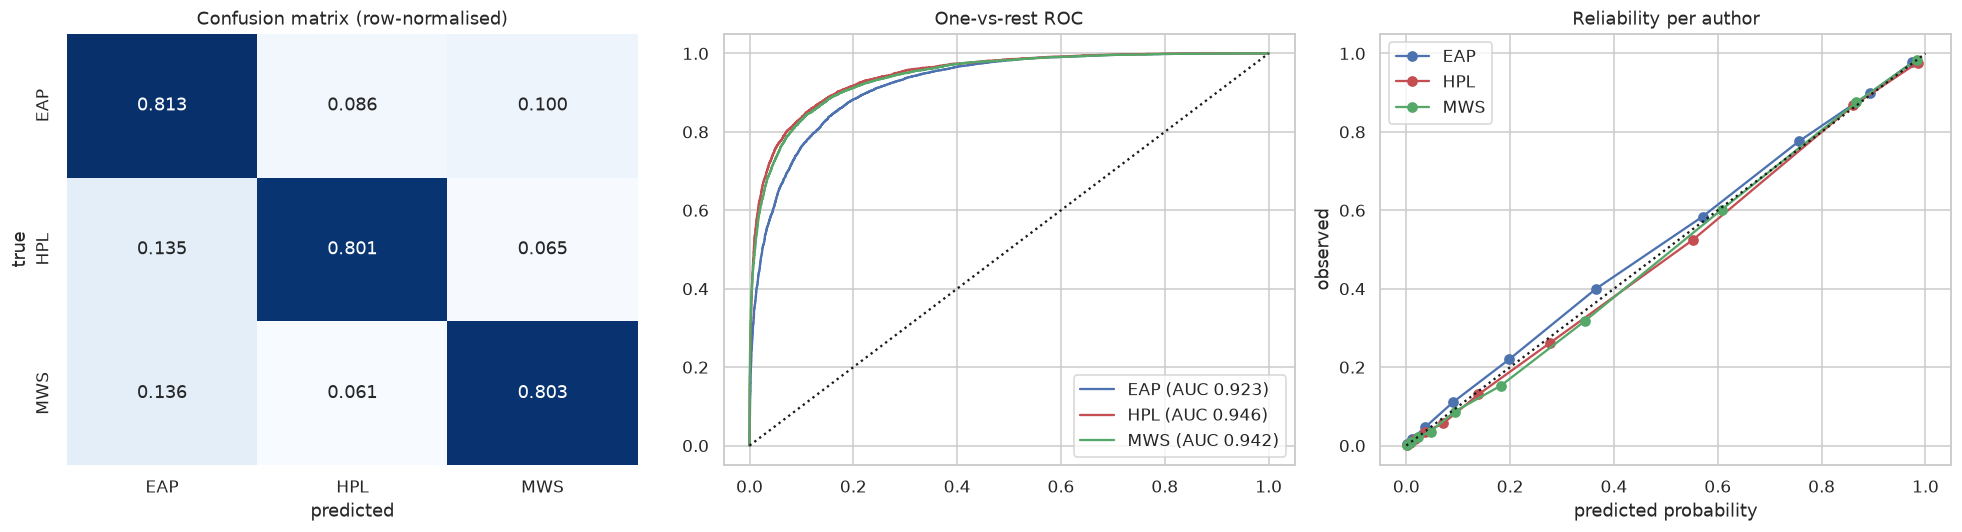

In [3]:
pred = cal.argmax(1); fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.heatmap(confusion_matrix(y, pred, normalize="true"), annot=True, fmt=".3f", cmap="Blues", ax=axes[0], cbar=False, xticklabels=AU, yticklabels=AU); axes[0].set_xlabel("predicted"); axes[0].set_ylabel("true"); axes[0].set_title("Confusion matrix (row-normalised)")
for c in range(3):
    f, t, _ = roc_curve(y == c, cal[:, c]); axes[1].plot(f, t, color=PAL[c], label=f"{AU[c]} (AUC {roc_auc_score(y == c, cal[:, c]):.3f})")
axes[1].plot([0, 1], [0, 1], "k:"); axes[1].legend(); axes[1].set_title("One-vs-rest ROC")
for c in range(3):
    fp, mp = calibration_curve(y == c, cal[:, c], n_bins=10, strategy="quantile"); axes[2].plot(mp, fp, "o-", color=PAL[c], label=AU[c])
axes[2].plot([0, 1], [0, 1], "k:"); axes[2].set_xlabel("predicted probability"); axes[2].set_ylabel("observed"); axes[2].legend(); axes[2].set_title("Reliability per author")
plt.tight_layout(); plt.savefig("assets/cnn_02_post_training_diagnostics.png", bbox_inches="tight"); plt.show()

### Which words does the network lean on? Gradient × embedding saliency

For four held-out sentences of fold 0 (the most confident correct sentence of each author and the most confident mistake), the contribution of each word token to the predicted author's logit,
$\sum_d \partial z_{\hat y}/\partial e_{t,d}\cdot e_{t,d}$ (word-branch embeddings; red raises the logit, blue lowers it).

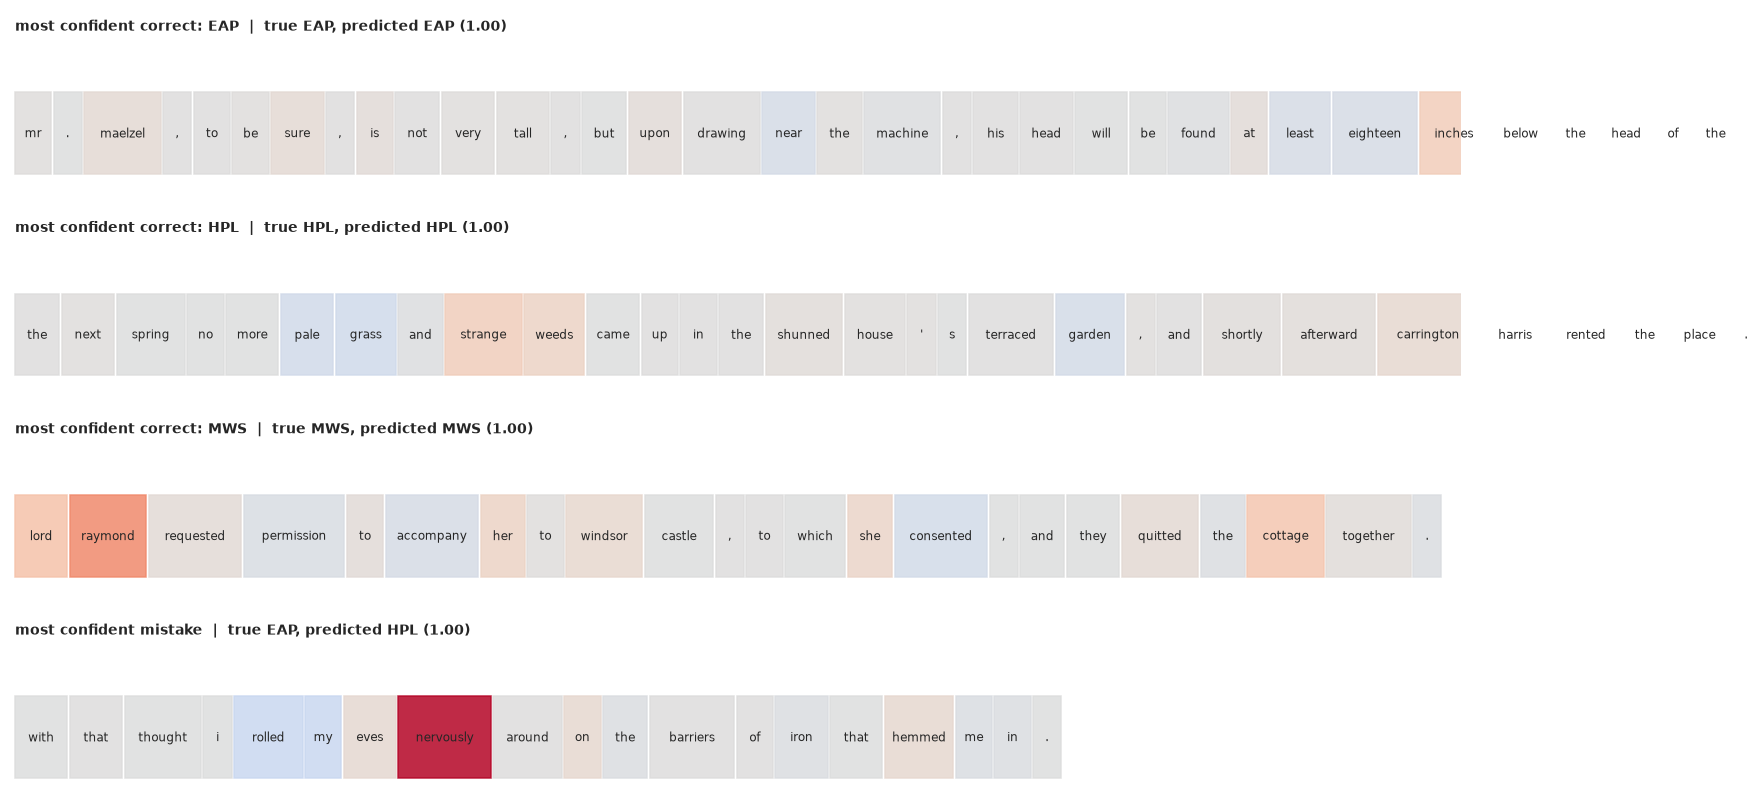

In [4]:
k0 = 0; tr0, va0 = np.where(folds != 0)[0], np.where(folds == 0)[0]
from sklearn.model_selection import train_test_split
i_tr, _ = train_test_split(np.arange(len(tr0)), test_size=0.1, stratify=y[tr0], random_state=0); txt = train.text.values
cv_ = TC.Vocab([ch for t in txt[tr0[i_tr]] for ch in t], 3); wv_ = TC.Vocab([w for t in txt[tr0[i_tr]] for w in TC.words_of(t)], 2)
model = TC.CharWordCNN(len(cv_), len(wv_), TC.CFG["char_dim"], TC.CFG["word_dim"], TC.CFG["char_channels"], TC.CFG["word_channels"], TC.CFG["dropout"]); model.load_state_dict(torch.load("checkpoints/cnn_f0.pt", map_location="cpu")); model.eval()
def saliency(text):
    xc = torch.tensor([cv_.encode(text, TC.MAX_CHARS)]); toks = TC.words_of(text)[:TC.MAX_WORDS]; xw = torch.tensor([wv_.encode(toks, TC.MAX_WORDS)])
    ew = model.we(xw).detach().requires_grad_(True); ec = model.ce(xc).transpose(1, 2)
    h = torch.cat([F.relu(c(ec)).max(2).values for c in model.cc] + [F.relu(c(ew.transpose(1, 2))).max(2).values for c in model.wc], 1); z = model.out(h)[0]; c = int(z.argmax()); z[c].backward()
    return toks, (ew.grad * ew.detach()).sum(-1)[0, :len(toks)].numpy(), c, float(F.softmax(z.detach(), 0)[c])
p0 = cal[va0]; y0 = y[va0]; picks = []
for a in range(3):
    ok = np.where((y0 == a) & (p0.argmax(1) == a))[0]; picks.append((f"most confident correct: {AU[a]}", ok[np.argmax(p0[ok, a])]))
bad = np.where(p0.argmax(1) != y0)[0]; picks.append(("most confident mistake", bad[np.argmax(p0[bad].max(1))]))
fig, axes = plt.subplots(4, 1, figsize=(16, 7.5)); sal = [saliency(txt[va0[i]]) for _, i in picks]; lim = max(np.abs(s).max() for _, s, _, _ in sal)
for ax, (name, i), (toks, s, c, p) in zip(axes, picks, sal):
    ax.set_xlim(0, 36); ax.set_ylim(0, 1); ax.axis("off"); x0 = 0.1; ax.text(x0, 0.95, f"{name}  |  true {AU[y0[i]]}, predicted {AU[c]} ({p:.2f})", fontsize=9, weight="bold", va="top")
    for w, v in zip(toks[:34], s[:34]):
        wd = 0.5 + 0.2 * len(w); ax.add_patch(Rectangle((x0, 0.1), wd, 0.45, color=plt.cm.coolwarm(0.5 + 0.5 * v / lim), alpha=.85)); ax.text(x0 + wd / 2, 0.32, w, ha="center", va="center", fontsize=8); x0 += wd + 0.06
plt.tight_layout(); plt.savefig("assets/cnn_03_token_saliency.png", bbox_inches="tight"); plt.show()